In [28]:
%load_ext autoreload
%autoreload 2

import requests
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm.auto import tqdm
import time
import matplotlib.pyplot as plt

from utils import (
    fetch_market_data, parse_future_name, bin_orderbook,
    compute_segment_carry, interpolate_forward, compute_continuous_forward_curve, add_mid_prices
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
start_date = datetime(2025, 1, 4)
end_date = start_date + timedelta(days=2)
inst_family = 'BTC-USD'
verbose = True
time_step_minutes = 1
swap_df = fetch_market_data(
    '6', 'SWAP', inst_family, start_date, end_date, 'daily',
    verbose=verbose, depth=1,
    include_criterion=lambda filename: filename.startswith(f'{inst_family}-SWAP'),
    process_fn=lambda df: bin_orderbook(df, f'{time_step_minutes}min')
)

# Fetch futures for forward curve construction
futures_df = fetch_market_data(
    '6', 'FUTURES', inst_family, start_date, end_date, 'daily',
    verbose=verbose, depth=1,
    include_criterion=lambda filename: filename.startswith(f'{inst_family}-'),
    process_fn=lambda df: bin_orderbook(df, f'{time_step_minutes}min')
)

Fetching SWAP data (module=6) for BTC-USD
Period: 2025-01-04 00:00:00 to 2025-01-06 00:00:00
Split into 2 requests


Fetching data:   0%|          | 0/2 [00:00<?, ?it/s]

Fetch #1/2: 1 files found | Total: 1 files, 231.20 MB


Fetch #2/2: 1 files found | Total: 2 files, 451.18 MB


✓ Successfully fetched 2881 records
Fetching FUTURES data (module=6) for BTC-USD
Period: 2025-01-04 00:00:00 to 2025-01-06 00:00:00
Split into 2 requests


Fetching data:   0%|          | 0/2 [00:00<?, ?it/s]

Fetch #1/2: 6 files found | Total: 6 files, 396.48 MB


Fetch #2/2: 6 files found | Total: 12 files, 828.73 MB


✓ Successfully fetched 17281 records


In [41]:
# Parse futures expiries
futures_df['expiry'] = futures_df['symbol'].apply(lambda x: parse_future_name(x)[1])

print(f"Swap records: {len(swap_df)}")
print(f"Futures records: {len(futures_df)}")
print(f"Unique futures symbols: {futures_df['symbol'].nunique()}")
print(f"Time range: {swap_df['time_bin'].min()} to {swap_df['time_bin'].max()}")


Swap records: 2881
Futures records: 17281
Unique futures symbols: 6
Time range: 2025-01-04 00:01:00 to 2025-01-06 00:00:00


In [54]:
print(all_segments_df.columns)

Index(['segment_num', 'T_start', 'T_end', 'F_lower_start', 'F_lower_end',
       'F_upper_start', 'F_upper_end', 'carry_lower', 'carry_upper',
       'expiry_start', 'expiry_end', 'symbol_start', 'symbol_end',
       'F_mid_start', 'F_mid_end', 'carry_mid', 'time_bin', 'segment_label'],
      dtype='object')


In [44]:
# Compute segment carry rates at a single timestamp
example_time = swap_df['time_bin'].iloc[500]  # Pick a timestamp
swap_row = swap_df[swap_df['time_bin'] == example_time].iloc[0]
swap_bid, swap_ask = swap_row['bid_1_px'], swap_row['ask_1_px']
futures_at_time = futures_df[futures_df['time_bin'] == example_time].copy()

segments = compute_segment_carry(futures_at_time, swap_bid, swap_ask, example_time)
segments = add_mid_prices(segments)

print(f"\nSegment carry rates at {example_time}:")
print(segments[['symbol_start', 'symbol_end', 'T_start', 'T_end', 
                'carry_lower', 'carry_upper', 'carry_mid']].to_string(index=False))



Segment carry rates at 2025-01-04 08:21:00:
     symbol_start        symbol_end  T_start    T_end  carry_lower  carry_upper  carry_mid
             SWAP BTC-USD-250110.OK 0.000000 0.016387     0.134681     0.136914   0.135797
BTC-USD-250110.OK BTC-USD-250117.OK 0.016387 0.035552     0.127500     0.130246   0.128873
BTC-USD-250117.OK BTC-USD-250131.OK 0.035552 0.073882     0.148270     0.148651   0.148460
BTC-USD-250131.OK BTC-USD-250228.OK 0.073882 0.150542     0.134020     0.134305   0.134163
BTC-USD-250228.OK BTC-USD-250328.OK 0.150542 0.227202     0.133069     0.131429   0.132249
BTC-USD-250328.OK BTC-USD-250627.OK 0.227202 0.476346     0.116925     0.117194   0.117060


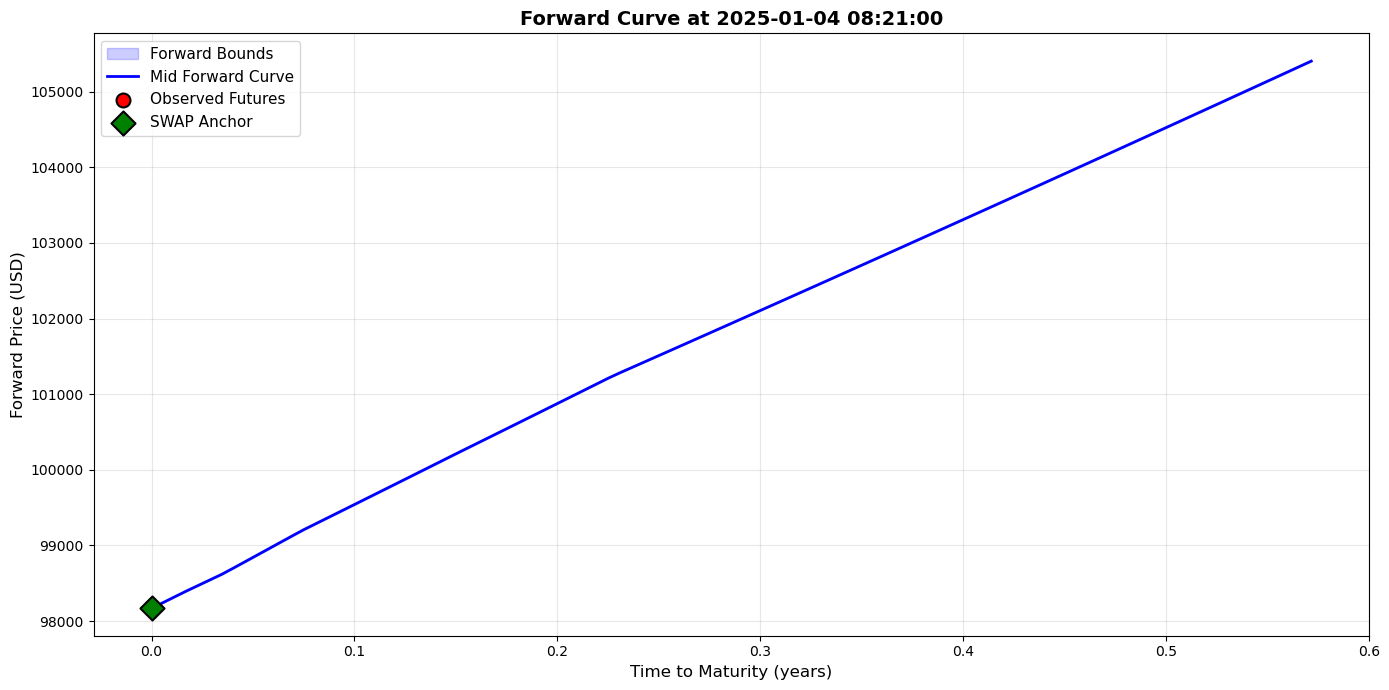


Forward curve computed with 100 points


In [45]:
# Compute continuous forward curve at the example timestamp
T_max = segments['T_end'].max()
T_grid = np.linspace(0, T_max * 1.2, 100)

forward_curve = compute_continuous_forward_curve(futures_at_time, swap_bid, swap_ask, example_time, T_grid)
forward_curve = add_mid_prices(forward_curve)

# Visualize the forward curve
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# Separate observed and interpolated points
observed = forward_curve[forward_curve['source'] == 'observed']
interpolated = forward_curve[forward_curve['source'].isin(['interpolated', 'swap'])]

# Plot bounds as shaded region
ax.fill_between(interpolated['T'], interpolated['F_lower'], interpolated['F_upper'], 
                alpha=0.2, color='blue', label='Forward Bounds')

# Plot mid forward curve
ax.plot(interpolated['T'], interpolated['F_mid'], 'b-', linewidth=2, label='Mid Forward Curve')

# Plot observed futures
ax.scatter(observed['T'], observed['F_mid'], color='red', s=100, zorder=3, 
          label='Observed Futures', edgecolors='black', linewidth=1.5)

# Mark the swap anchor
swap_point = forward_curve[forward_curve['source'] == 'swap'].iloc[0]
ax.scatter([swap_point['T']], [(swap_point['F_lower'] + swap_point['F_upper'])/2], 
          color='green', s=150, zorder=4, marker='D', 
          label='SWAP Anchor', edgecolors='black', linewidth=1.5)

ax.set_xlabel('Time to Maturity (years)', fontsize=12)
ax.set_ylabel('Forward Price (USD)', fontsize=12)
ax.set_title(f'Forward Curve at {example_time}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForward curve computed with {len(forward_curve)} points")


In [46]:
# Compute segment carry rates over ALL timestamps
all_segments = []

for _, swap_row in swap_df.iterrows():
    time_bin = swap_row['time_bin']
    swap_bid, swap_ask = swap_row['bid_1_px'], swap_row['ask_1_px']
    
    futures_at_time = futures_df[futures_df['time_bin'] == time_bin].copy()
    if len(futures_at_time) == 0:
        continue
    
    segments_df = compute_segment_carry(futures_at_time, swap_bid, swap_ask, time_bin, min_time_to_expiry=4.0)
    segments_df = add_mid_prices(segments_df)
    segments_df['time_bin'] = time_bin
    all_segments.append(segments_df)

all_segments_df = pd.concat(all_segments, ignore_index=True)

print(f"\nComputed {len(all_segments_df)} segment observations across time")
print(f"Time range: {all_segments_df['time_bin'].min()} to {all_segments_df['time_bin'].max()}")



Computed 17288 segment observations across time
Time range: 2025-01-04 00:01:00 to 2025-01-06 00:00:00


In [73]:
# It seems we're getting some weird segments that are not normal.
# Let's look at them:
print("Nonexistent symbol start")
print(all_segments_df[all_segments_df['symbol_start'].isna()]['symbol_start', 'symbol_end', 'time_bin'])
print("Same symbol start and end")
print(all_segments_df[all_segments_df['symbol_start'] == all_segments_df['symbol_end']]['symbol_start', 'symbol_end', 'time_bin'])


Nonexistent symbol start


KeyError: ('symbol_start', 'symbol_end', 'time_bin')

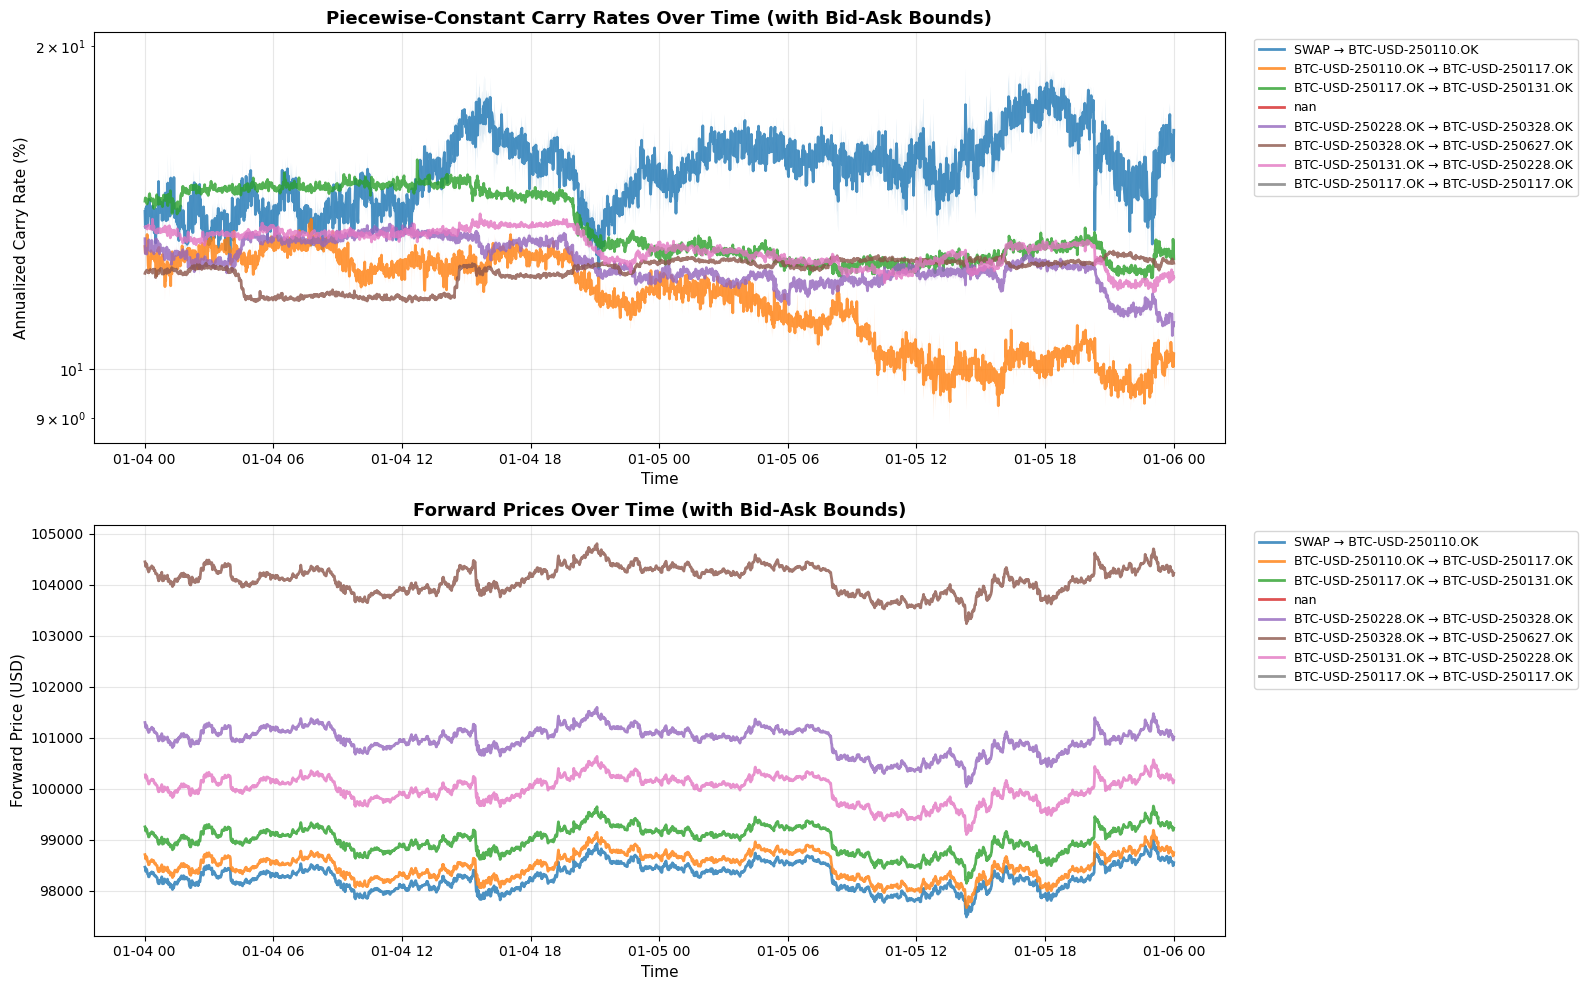

In [47]:
# Visualize carry rates over time for different segments
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Create segment labels
all_segments_df['segment_label'] = all_segments_df['symbol_start'] + ' → ' + all_segments_df['symbol_end']

# Plot 1: Carry rates with bounds
for segment_label in all_segments_df['segment_label'].unique():
    segment_data = all_segments_df[all_segments_df['segment_label'] == segment_label]
    
    # Plot mid carry rate (now in percent)
    axes[0].plot(segment_data['time_bin'], segment_data['carry_mid'] * 100, 
                 label=segment_label, linewidth=2, alpha=0.8)
    
    # Add shaded region for bounds (convert to percent)
    axes[0].fill_between(segment_data['time_bin'], 
                         segment_data['carry_lower'] * 100, 
                         segment_data['carry_upper'] * 100,
                         alpha=0.15)

axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('Annualized Carry Rate (%)', fontsize=11)
axes[0].set_title('Piecewise-Constant Carry Rates Over Time (with Bid-Ask Bounds)', fontsize=13, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Forward prices with bounds
for segment_label in all_segments_df['segment_label'].unique():
    segment_data = all_segments_df[all_segments_df['segment_label'] == segment_label]
    
    # Plot mid forward
    axes[1].plot(segment_data['time_bin'], segment_data['F_mid_end'], 
                 label=segment_label, linewidth=2, alpha=0.8)
    
    # Add shaded region for bounds
    axes[1].fill_between(segment_data['time_bin'], 
                         segment_data['F_lower_end'], 
                         segment_data['F_upper_end'],
                         alpha=0.15)

axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_ylabel('Forward Price (USD)', fontsize=11)
axes[1].set_title('Forward Prices Over Time (with Bid-Ask Bounds)', fontsize=13, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [71]:
# To get all unique combinations across multiple columns, use .drop_duplicates() or .drop_duplicates().values
print(len(all_segments_df[all_segments_df['symbol_start'].isna()]))
# Normal segments:
for label in all_segments_df['segment_label'].unique():
    print(label)
    print(len(all_segments_df[all_segments_df['segment_label'] == label]))

1
SWAP → BTC-USD-250110.OK
2881
BTC-USD-250110.OK → BTC-USD-250117.OK
2881
BTC-USD-250117.OK → BTC-USD-250131.OK
2881
nan
0
BTC-USD-250228.OK → BTC-USD-250328.OK
2881
BTC-USD-250328.OK → BTC-USD-250627.OK
2881
BTC-USD-250131.OK → BTC-USD-250228.OK
2880
BTC-USD-250117.OK → BTC-USD-250117.OK
2


In [49]:
# Summary statistics of carry rates by segment
summary = all_segments_df.groupby('segment_label').agg({
    'carry_mid': ['mean', 'std', 'min', 'max'],
    'carry_lower': ['mean', 'std'],
    'carry_upper': ['mean', 'std'],
    'T_start': 'first',
    'T_end': 'first'
}).round(4)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.sort_values('T_start_first')

print("\nCarry Rate Statistics by Segment:")
print(summary)



Carry Rate Statistics by Segment:
                                       carry_mid_mean  carry_mid_std  \
segment_label                                                          
SWAP → BTC-USD-250110.OK                       0.1534         0.0117   
BTC-USD-250110.OK → BTC-USD-250117.OK          0.1161         0.0114   
BTC-USD-250117.OK → BTC-USD-250117.OK          0.0000         0.0000   
BTC-USD-250117.OK → BTC-USD-250131.OK          0.1360         0.0099   
BTC-USD-250131.OK → BTC-USD-250228.OK          0.1299         0.0047   
BTC-USD-250228.OK → BTC-USD-250328.OK          0.1256         0.0058   
BTC-USD-250328.OK → BTC-USD-250627.OK          0.1234         0.0037   

                                       carry_mid_min  carry_mid_max  \
segment_label                                                         
SWAP → BTC-USD-250110.OK                      0.1241         0.1859   
BTC-USD-250110.OK → BTC-USD-250117.OK         0.0925         0.1380   
BTC-USD-250117.OK → BTC-USD-2501

In [50]:
# Demonstrate interpolation for arbitrary maturities
print("Forward interpolation examples:")
print("-" * 80)

test_maturities = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]  # Various maturities in years

for T_test in test_maturities:
    F_bounds = interpolate_forward(T_test, segments)
    if F_bounds is not None:
        F_lower, F_upper = F_bounds
        F_mid = (F_lower + F_upper) / 2
        spread_bps = ((F_upper - F_lower) / F_mid) * 10000
        
        days = T_test * 365.25
        print(f"T = {T_test:.3f}y (~{days:.0f} days):")
        print(f"  F_lower = ${F_lower:,.2f}  |  F_mid = ${F_mid:,.2f}  |  F_upper = ${F_upper:,.2f}")
        print(f"  Bid-Ask Spread: {spread_bps:.2f} bps")
        print()


Forward interpolation examples:
--------------------------------------------------------------------------------
T = 0.010y (~4 days):
  F_lower = $98,300.20  |  F_mid = $98,301.35  |  F_upper = $98,302.50
  Bid-Ask Spread: 0.23 bps

T = 0.050y (~18 days):
  F_lower = $98,837.00  |  F_mid = $98,841.73  |  F_upper = $98,846.46
  Bid-Ask Spread: 0.96 bps

T = 0.100y (~37 days):
  F_lower = $99,535.40  |  F_mid = $99,540.99  |  F_upper = $99,546.58
  Bid-Ask Spread: 1.12 bps

T = 0.200y (~73 days):
  F_lower = $100,873.61  |  F_mid = $100,875.91  |  F_upper = $100,878.21
  Bid-Ask Spread: 0.46 bps

T = 0.300y (~110 days):
  F_lower = $102,104.82  |  F_mid = $102,105.87  |  F_upper = $102,106.92
  Bid-Ask Spread: 0.21 bps

T = 0.400y (~146 days):
  F_lower = $103,305.69  |  F_mid = $103,308.14  |  F_upper = $103,310.60
  Bid-Ask Spread: 0.48 bps



NOISE ANALYSIS (Normalized for Tenor Length)

Noise Metrics by Segment:
                        segment_label  tenor_days  carry_mean  carry_std  noise_per_sqrt_year  carry_cv  autocorr_1
BTC-USD-250117.OK → BTC-USD-250117.OK    0.000000    0.000000   0.000000                  NaN       NaN         NaN
             SWAP → BTC-USD-250110.OK    6.332639   15.337944   1.174455             8.919469  0.076572    0.921148
BTC-USD-250110.OK → BTC-USD-250117.OK    7.000000   11.614100   1.137172             8.214332  0.097913    0.984376
BTC-USD-250117.OK → BTC-USD-250131.OK   14.000000   13.601671   0.986217             5.037366  0.072507    0.993669
BTC-USD-250228.OK → BTC-USD-250328.OK   28.000000   12.560512   0.580553             2.096806  0.046221    0.986847
BTC-USD-250131.OK → BTC-USD-250228.OK   28.000000   12.993481   0.474195             1.712667  0.036495    0.990316
BTC-USD-250328.OK → BTC-USD-250627.OK   91.000000   12.344485   0.367589             0.736440  0.029778    0.995227


/opt/anaconda3/envs/ml_env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/anaconda3/envs/ml_env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/envs/ml_env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


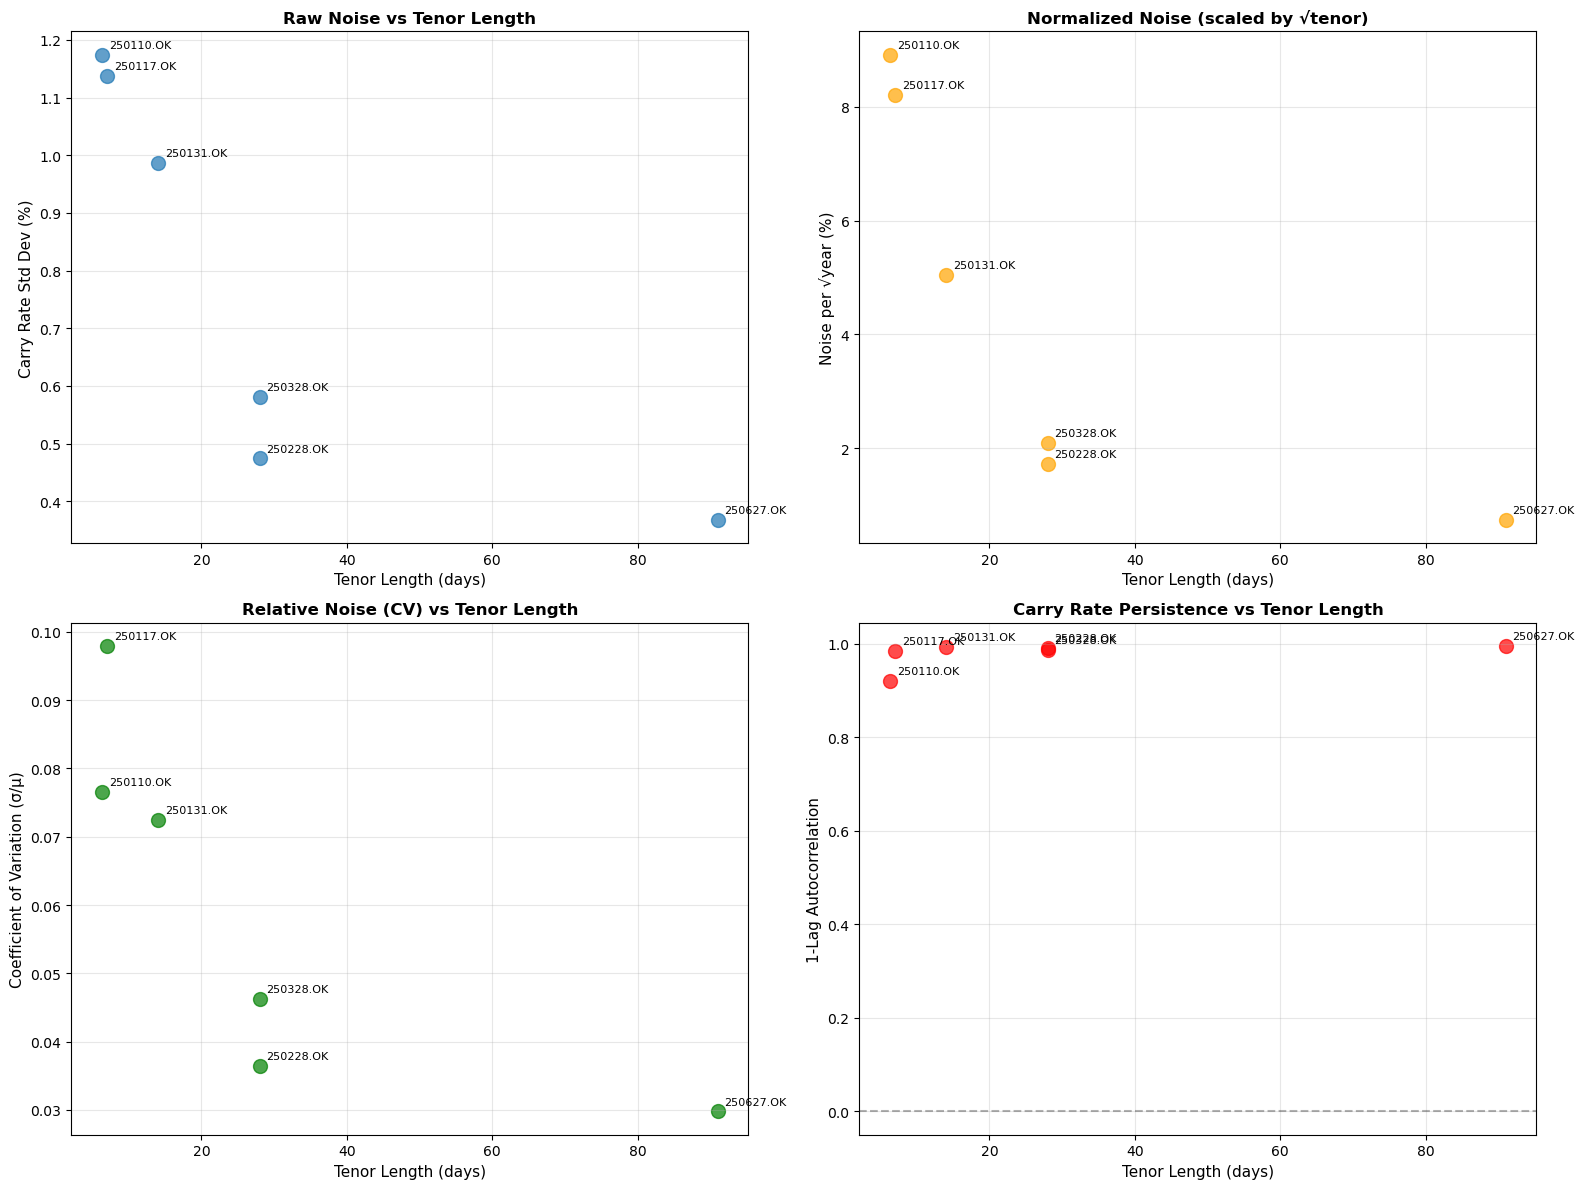


KEY OBSERVATIONS:
• Shortest tenor (SWAP→BTC-USD-250110.OK):
  - Tenor: 6.3 days
  - Raw std: 1.174%
  - Normalized noise: 8.919% per √year

• Longest tenor (BTC-USD-250328.OK→BTC-USD-250627.OK):
  - Tenor: 91.0 days
  - Raw std: 0.368%
  - Normalized noise: 0.736% per √year

• Noise ratio (shortest/longest): 3.20x
• Normalized noise ratio: 12.11x


In [56]:
# ============================================================================
# NOISE ANALYSIS: Normalized for Tenor Length
# ============================================================================

print("="*80)
print("NOISE ANALYSIS (Normalized for Tenor Length)")
print("="*80)

# Compute noise metrics for each segment, skip segments where group is empty
noise_analysis = []
for segment_label in all_segments_df['segment_label'].unique():
    segment_data = all_segments_df[all_segments_df['segment_label'] == segment_label]
    
    if segment_data.empty:
        continue  # Skip empty segments to avoid index errors

    # Defensive: confirm that T_start and T_end exist and have at least one value
    if segment_data['T_end'].empty or segment_data['T_start'].empty:
        tenor_length = np.nan
        tenor_days = np.nan
    else:
        tenor_length = (segment_data['T_end'] - segment_data['T_start']).iloc[0]
        tenor_days = tenor_length * 365.25 if pd.notnull(tenor_length) else np.nan

    # Compute various noise metrics (carry rates are in decimal form, convert to % for display)
    carry_std = segment_data['carry_mid'].std() * 100  # Convert to %
    carry_mean = segment_data['carry_mid'].mean() * 100  # Convert to %
    carry_cv = carry_std / carry_mean if carry_mean != 0 else np.nan  # Coefficient of variation

    # Normalize by tenor length (avoid division by zero/nan)
    noise_per_year = carry_std / np.sqrt(tenor_length) if tenor_length and tenor_length > 0 else np.nan

    # Compute bid-ask spread statistics
    spread_mean = (segment_data['carry_upper'] - segment_data['carry_lower']).mean() * 100
    spread_std = (segment_data['carry_upper'] - segment_data['carry_lower']).std() * 100

    # Compute first-order autocorrelation to measure persistence
    carry_series = segment_data.sort_values('time_bin')['carry_mid']
    autocorr_1 = carry_series.autocorr(lag=1) if len(carry_series) > 1 else np.nan

    noise_analysis.append({
        'segment_label': segment_label,
        'tenor_years': tenor_length,
        'tenor_days': tenor_days,
        'carry_mean': carry_mean,
        'carry_std': carry_std,
        'carry_cv': carry_cv,
        'noise_per_sqrt_year': noise_per_year,
        'spread_mean': spread_mean,
        'spread_std': spread_std,
        'autocorr_1': autocorr_1,
        'symbol_start': segment_data['symbol_start'].iloc[0] if not segment_data['symbol_start'].empty else "",
        'symbol_end': segment_data['symbol_end'].iloc[0] if not segment_data['symbol_end'].empty else ""
    })

noise_df = pd.DataFrame(noise_analysis).sort_values('tenor_years')
print("\nNoise Metrics by Segment:")
print(noise_df[['segment_label', 'tenor_days', 'carry_mean', 'carry_std', 
                'noise_per_sqrt_year', 'carry_cv', 'autocorr_1']].to_string(index=False))

# Visualize noise patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Exclude zero- or nan-length segments for plots and summary
noise_df_plot = noise_df[(noise_df['tenor_days'] > 0) & (noise_df['tenor_days'].notna())]

# Plot 1: Standard deviation vs tenor length
ax = axes[0, 0]
ax.scatter(noise_df_plot['tenor_days'], noise_df_plot['carry_std'], s=100, alpha=0.7)
for _, row in noise_df_plot.iterrows():
    ax.annotate(row['symbol_end'].split('-')[-1], 
                (row['tenor_days'], row['carry_std']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Tenor Length (days)', fontsize=11)
ax.set_ylabel('Carry Rate Std Dev (%)', fontsize=11)
ax.set_title('Raw Noise vs Tenor Length', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 2: Normalized noise (noise per sqrt(year))
ax = axes[0, 1]
ax.scatter(noise_df_plot['tenor_days'], noise_df_plot['noise_per_sqrt_year'], 
           s=100, alpha=0.7, color='orange')
for _, row in noise_df_plot.iterrows():
    ax.annotate(row['symbol_end'].split('-')[-1], 
                (row['tenor_days'], row['noise_per_sqrt_year']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Tenor Length (days)', fontsize=11)
ax.set_ylabel('Noise per √year (%)', fontsize=11)
ax.set_title('Normalized Noise (scaled by √tenor)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Coefficient of variation
ax = axes[1, 0]
ax.scatter(noise_df_plot['tenor_days'], noise_df_plot['carry_cv'], 
           s=100, alpha=0.7, color='green')
for _, row in noise_df_plot.iterrows():
    ax.annotate(row['symbol_end'].split('-')[-1], 
                (row['tenor_days'], row['carry_cv']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Tenor Length (days)', fontsize=11)
ax.set_ylabel('Coefficient of Variation (σ/μ)', fontsize=11)
ax.set_title('Relative Noise (CV) vs Tenor Length', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: Autocorrelation (persistence)
ax = axes[1, 1]
ax.scatter(noise_df_plot['tenor_days'], noise_df_plot['autocorr_1'], 
           s=100, alpha=0.7, color='red')
for _, row in noise_df_plot.iterrows():
    ax.annotate(row['symbol_end'].split('-')[-1], 
                (row['tenor_days'], row['autocorr_1']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Tenor Length (days)', fontsize=11)
ax.set_ylabel('1-Lag Autocorrelation', fontsize=11)
ax.set_title('Carry Rate Persistence vs Tenor Length', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY OBSERVATIONS:")
print("="*80)
# Only print observations if at least one row remains for shortest and longest tenors
if not noise_df_plot.empty:
    idx_shortest = noise_df_plot.index[0]
    idx_longest = noise_df_plot.index[-1]
    print(f"• Shortest tenor (SWAP→{noise_df_plot.loc[idx_shortest, 'symbol_end']}):")
    print(f"  - Tenor: {noise_df_plot.loc[idx_shortest, 'tenor_days']:.1f} days")
    print(f"  - Raw std: {noise_df_plot.loc[idx_shortest, 'carry_std']:.3f}%")
    print(f"  - Normalized noise: {noise_df_plot.loc[idx_shortest, 'noise_per_sqrt_year']:.3f}% per √year")
    print(f"\n• Longest tenor ({noise_df_plot.loc[idx_longest, 'symbol_start']}→{noise_df_plot.loc[idx_longest, 'symbol_end']}):")
    print(f"  - Tenor: {noise_df_plot.loc[idx_longest, 'tenor_days']:.1f} days")
    print(f"  - Raw std: {noise_df_plot.loc[idx_longest, 'carry_std']:.3f}%")
    print(f"  - Normalized noise: {noise_df_plot.loc[idx_longest, 'noise_per_sqrt_year']:.3f}% per √year")
    if noise_df_plot.loc[idx_longest, 'carry_std'] != 0 and noise_df_plot.loc[idx_longest, 'noise_per_sqrt_year'] != 0:
        print(f"\n• Noise ratio (shortest/longest): {noise_df_plot.loc[idx_shortest, 'carry_std'] / noise_df_plot.loc[idx_longest, 'carry_std']:.2f}x")
        print(f"• Normalized noise ratio: {noise_df_plot.loc[idx_shortest, 'noise_per_sqrt_year'] / noise_df_plot.loc[idx_longest, 'noise_per_sqrt_year']:.2f}x")
    else:
        print(f"\n• Noise ratio (shortest/longest): N/A (division by zero)")
        print(f"• Normalized noise ratio: N/A (division by zero)")
else:
    print("No valid segments available for key observation summaries.")



COVARIANCE & CORRELATION ANALYSIS


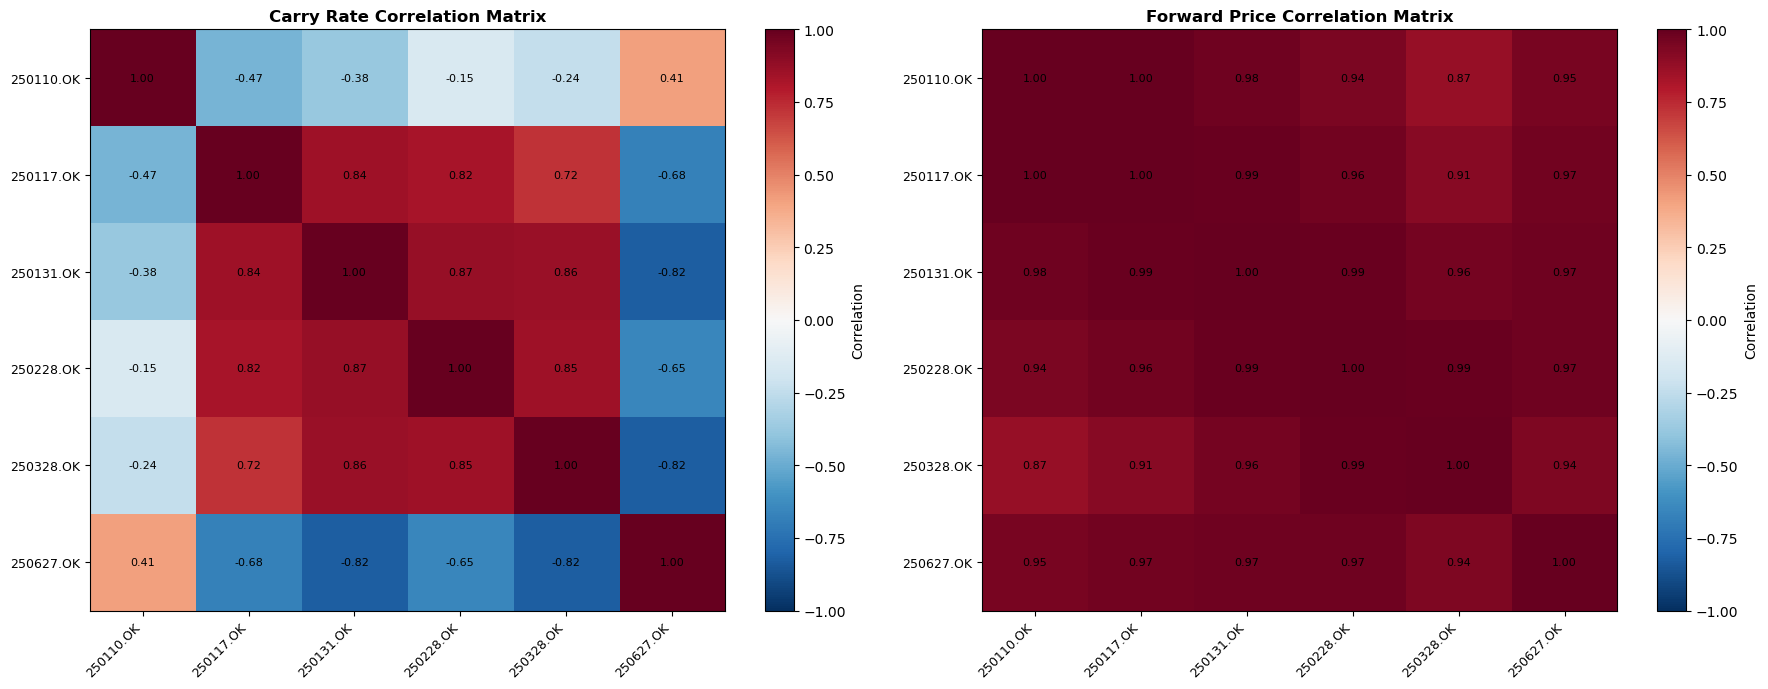


Carry Rate Correlation Summary:
--------------------------------------------------------------------------------
Mean correlation: 0.0781
Median correlation: -0.1548
Min correlation: -0.8215
Max correlation: 0.8673
Std of correlations: 0.6776

Forward Price Correlation Summary:
--------------------------------------------------------------------------------
Mean correlation: 0.9585
Median correlation: 0.9671
Min correlation: 0.8721
Max correlation: 0.9965
Std of correlations: 0.0327

TIME-VARYING CORRELATION ANALYSIS


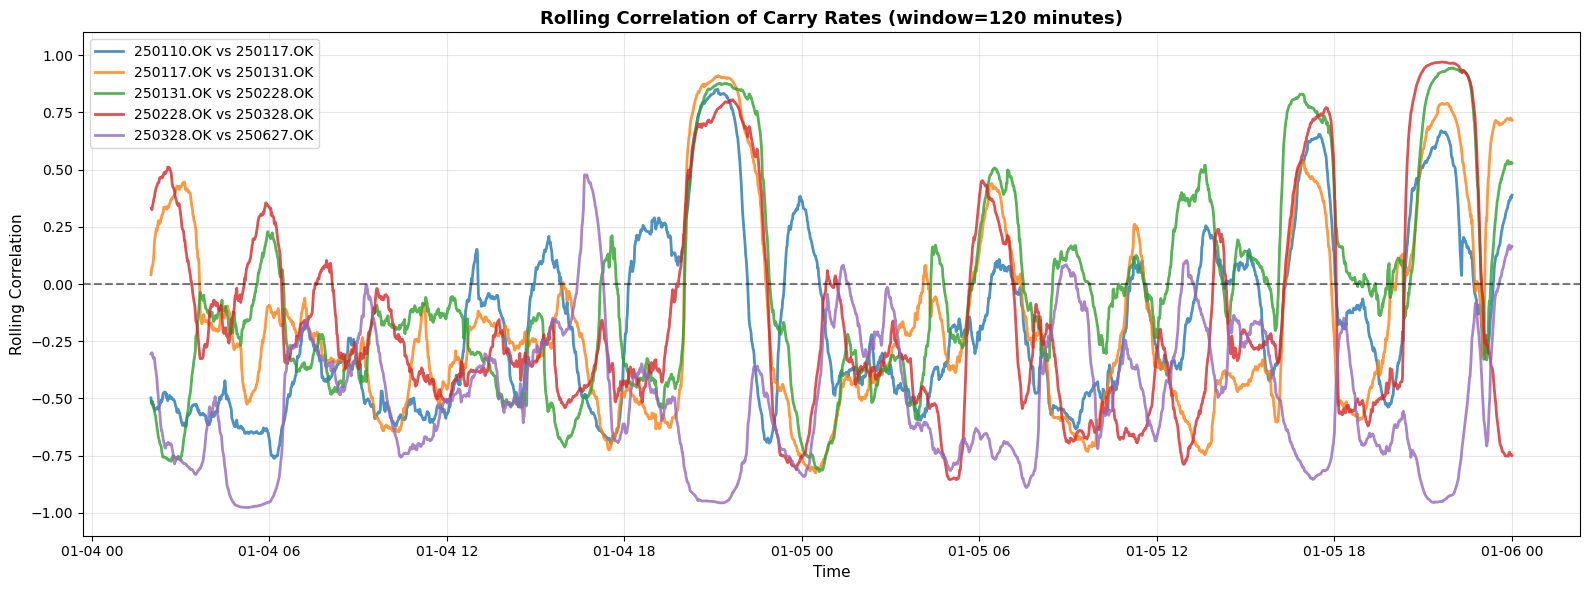


Rolling Correlation Statistics:
--------------------------------------------------------------------------------

250110.OK vs 250117.OK:
  Mean: -0.1752
  Std: 0.3818
  Min: -0.7622
  Max: 0.8512
  Range: 1.6134
  % of time corr < 0.5: 91.81%
  % of time corr < 0.0: 68.78%

250117.OK vs 250131.OK:
  Mean: -0.1656
  Std: 0.4267
  Min: -0.8253
  Max: 0.9108
  Range: 1.7361
  % of time corr < 0.5: 89.57%
  % of time corr < 0.0: 73.60%

250131.OK vs 250228.OK:
  Mean: -0.0336
  Std: 0.4361
  Min: -0.8195
  Max: 0.9447
  Range: 1.7643
  % of time corr < 0.5: 85.87%
  % of time corr < 0.0: 61.01%

250228.OK vs 250328.OK:
  Mean: -0.1496
  Std: 0.4593
  Min: -0.8552
  Max: 0.9700
  Range: 1.8252
  % of time corr < 0.5: 86.85%
  % of time corr < 0.0: 72.21%

250328.OK vs 250627.OK:
  Mean: -0.4993
  Std: 0.2985
  Min: -0.9767
  Max: 0.4776
  Range: 1.4543
  % of time corr < 0.5: 100.00%
  % of time corr < 0.0: 94.39%


In [59]:
# ============================================================================
# COVARIANCE & CORRELATION ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("COVARIANCE & CORRELATION ANALYSIS")
print("="*80)

# Create pivot tables for carry rates and forward prices
# Note: carry rates are in decimal form, will convert to % for display
carry_pivot = all_segments_df.pivot_table(
    index='time_bin', 
    columns='segment_label', 
    values='carry_mid'
) * 100  # Convert to %

forward_pivot = all_segments_df.pivot_table(
    index='time_bin', 
    columns='segment_label', 
    values='F_mid_end'
)

# Remove segments with all NaN or zero variance (like the BTC-USD-250117.OK → BTC-USD-250117.OK segment)
carry_pivot = carry_pivot.loc[:, carry_pivot.std() > 1e-6]
forward_pivot = forward_pivot.loc[:, forward_pivot.std() > 1e-6]

# ---- SORT segment columns by expiry for covariance/correlation ----
def extract_expiry(seg_label):
    # Expects segment_label such as 'BTC-USD-240524.OK→BTC-USD-240628.OK'
    # Will grab the END contract's expiry string, e.g., '240628'
    try:
        end_part = seg_label.split('→')[-1]
        # Find last '-' (works for "BTC-USD-240628.OK")
        expiry_str = end_part.split('-')[-1]
        # Remove possible .OK, .PERP suffixes
        expiry = ''.join(filter(str.isdigit, expiry_str))
        return int(expiry) if expiry.isdigit() else 0
    except Exception:
        return 0

sorted_cols = sorted(list(carry_pivot.columns), key=extract_expiry)
carry_pivot = carry_pivot[sorted_cols]
forward_pivot = forward_pivot[sorted_cols]

# Compute correlation matrices (sorted by expiry)
carry_corr = carry_pivot.corr()
forward_corr = forward_pivot.corr()

# Compute covariance matrices (sorted by expiry)
carry_cov = carry_pivot.cov()
forward_cov = forward_pivot.cov()

# Create figure with correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Carry rate correlations
ax = axes[0]
im1 = ax.imshow(carry_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(carry_corr.columns)))
ax.set_yticks(range(len(carry_corr.columns)))
ax.set_xticklabels([col.split('→')[-1].split('-')[-1] for col in carry_corr.columns], 
                    rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([col.split('→')[-1].split('-')[-1] for col in carry_corr.columns], 
                    fontsize=9)
ax.set_title('Carry Rate Correlation Matrix', fontsize=12, fontweight='bold')

# Add correlation values to cells
for i in range(len(carry_corr)):
    for j in range(len(carry_corr.columns)):
        text = ax.text(j, i, f'{carry_corr.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im1, ax=ax, label='Correlation')

# Plot 2: Forward price correlations
ax = axes[1]
im2 = ax.imshow(forward_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(forward_corr.columns)))
ax.set_yticks(range(len(forward_corr.columns)))
ax.set_xticklabels([col.split('→')[-1].split('-')[-1] for col in forward_corr.columns], 
                    rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([col.split('→')[-1].split('-')[-1] for col in forward_corr.columns], 
                    fontsize=9)
ax.set_title('Forward Price Correlation Matrix', fontsize=12, fontweight='bold')

# Add correlation values to cells
for i in range(len(forward_corr)):
    for j in range(len(forward_corr.columns)):
        text = ax.text(j, i, f'{forward_corr.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im2, ax=ax, label='Correlation')

plt.tight_layout()
plt.show()

# Print correlation statistics
print("\nCarry Rate Correlation Summary:")
print("-" * 80)
# Get off-diagonal correlations
carry_corr_triu = np.triu(carry_corr.values, k=1)
carry_corr_offdiag = carry_corr_triu[carry_corr_triu != 0]
print(f"Mean correlation: {carry_corr_offdiag.mean():.4f}")
print(f"Median correlation: {np.median(carry_corr_offdiag):.4f}")
print(f"Min correlation: {carry_corr_offdiag.min():.4f}")
print(f"Max correlation: {carry_corr_offdiag.max():.4f}")
print(f"Std of correlations: {carry_corr_offdiag.std():.4f}")

print("\nForward Price Correlation Summary:")
print("-" * 80)
forward_corr_triu = np.triu(forward_corr.values, k=1)
forward_corr_offdiag = forward_corr_triu[forward_corr_triu != 0]
print(f"Mean correlation: {forward_corr_offdiag.mean():.4f}")
print(f"Median correlation: {np.median(forward_corr_offdiag):.4f}")
print(f"Min correlation: {forward_corr_offdiag.min():.4f}")
print(f"Max correlation: {forward_corr_offdiag.max():.4f}")
print(f"Std of correlations: {forward_corr_offdiag.std():.4f}")

# Analyze rolling correlations to see if correlation changes over time
print("\n" + "="*80)
print("TIME-VARYING CORRELATION ANALYSIS")
print("="*80)

# For every pair of successive segments, analyze rolling correlation (not just 3)
pairs_to_analyze = []
segment_labels = list(carry_pivot.columns)
for i in range(len(segment_labels) - 1):
    pairs_to_analyze.append((segment_labels[i], segment_labels[i+1]))

# Compute rolling correlations
window = 120  # 2 hours with 1-minute bins
rolling_corrs = {}

for label1, label2 in pairs_to_analyze:
    if label1 in carry_pivot.columns and label2 in carry_pivot.columns:
        rolling_corr = carry_pivot[label1].rolling(window=window).corr(carry_pivot[label2])
        key = f"{label1.split('→')[-1].split('-')[-1]} vs {label2.split('→')[-1].split('-')[-1]}"
        rolling_corrs[key] = rolling_corr

# Plot rolling correlations
if rolling_corrs:
    fig, ax = plt.subplots(1, 1, figsize=(16, 6))
    
    for pair_label, rolling_corr in rolling_corrs.items():
        ax.plot(rolling_corr.index, rolling_corr.values, label=pair_label, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Time', fontsize=11)
    ax.set_ylabel('Rolling Correlation', fontsize=11)
    ax.set_title(f'Rolling Correlation of Carry Rates (window={window} minutes)', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax.set_ylim(-1.1, 1.1)
    plt.tight_layout()
    plt.show()
    
    # Print statistics about correlation stability
    print("\nRolling Correlation Statistics:")
    print("-" * 80)
    for pair_label, rolling_corr in rolling_corrs.items():
        valid_corrs = rolling_corr.dropna()
        if len(valid_corrs) > 0:
            print(f"\n{pair_label}:")
            print(f"  Mean: {valid_corrs.mean():.4f}")
            print(f"  Std: {valid_corrs.std():.4f}")
            print(f"  Min: {valid_corrs.min():.4f}")
            print(f"  Max: {valid_corrs.max():.4f}")
            print(f"  Range: {valid_corrs.max() - valid_corrs.min():.4f}")
            
            # Count how often correlation drops below certain thresholds
            pct_below_05 = (valid_corrs < 0.5).sum() / len(valid_corrs) * 100
            pct_below_0 = (valid_corrs < 0).sum() / len(valid_corrs) * 100
            print(f"  % of time corr < 0.5: {pct_below_05:.2f}%")
            print(f"  % of time corr < 0.0: {pct_below_0:.2f}%")



CORRELATION BREAKDOWN ANALYSIS

Analyzing correlation between:
  Segment 1: SWAP → BTC-USD-250110.OK
  Segment 2: BTC-USD-250110.OK → BTC-USD-250117.OK

Periods with correlation < 0.3 (using 30-min window):
  Total time periods: 2848
  Percentage of time: 99.93%

  Examples of low correlation periods:
    2025-01-04 00:31:00: correlation = -0.203
    2025-01-04 00:32:00: correlation = -0.239
    2025-01-04 00:33:00: correlation = -0.208
    2025-01-04 00:34:00: correlation = -0.208
    2025-01-04 00:35:00: correlation = -0.199


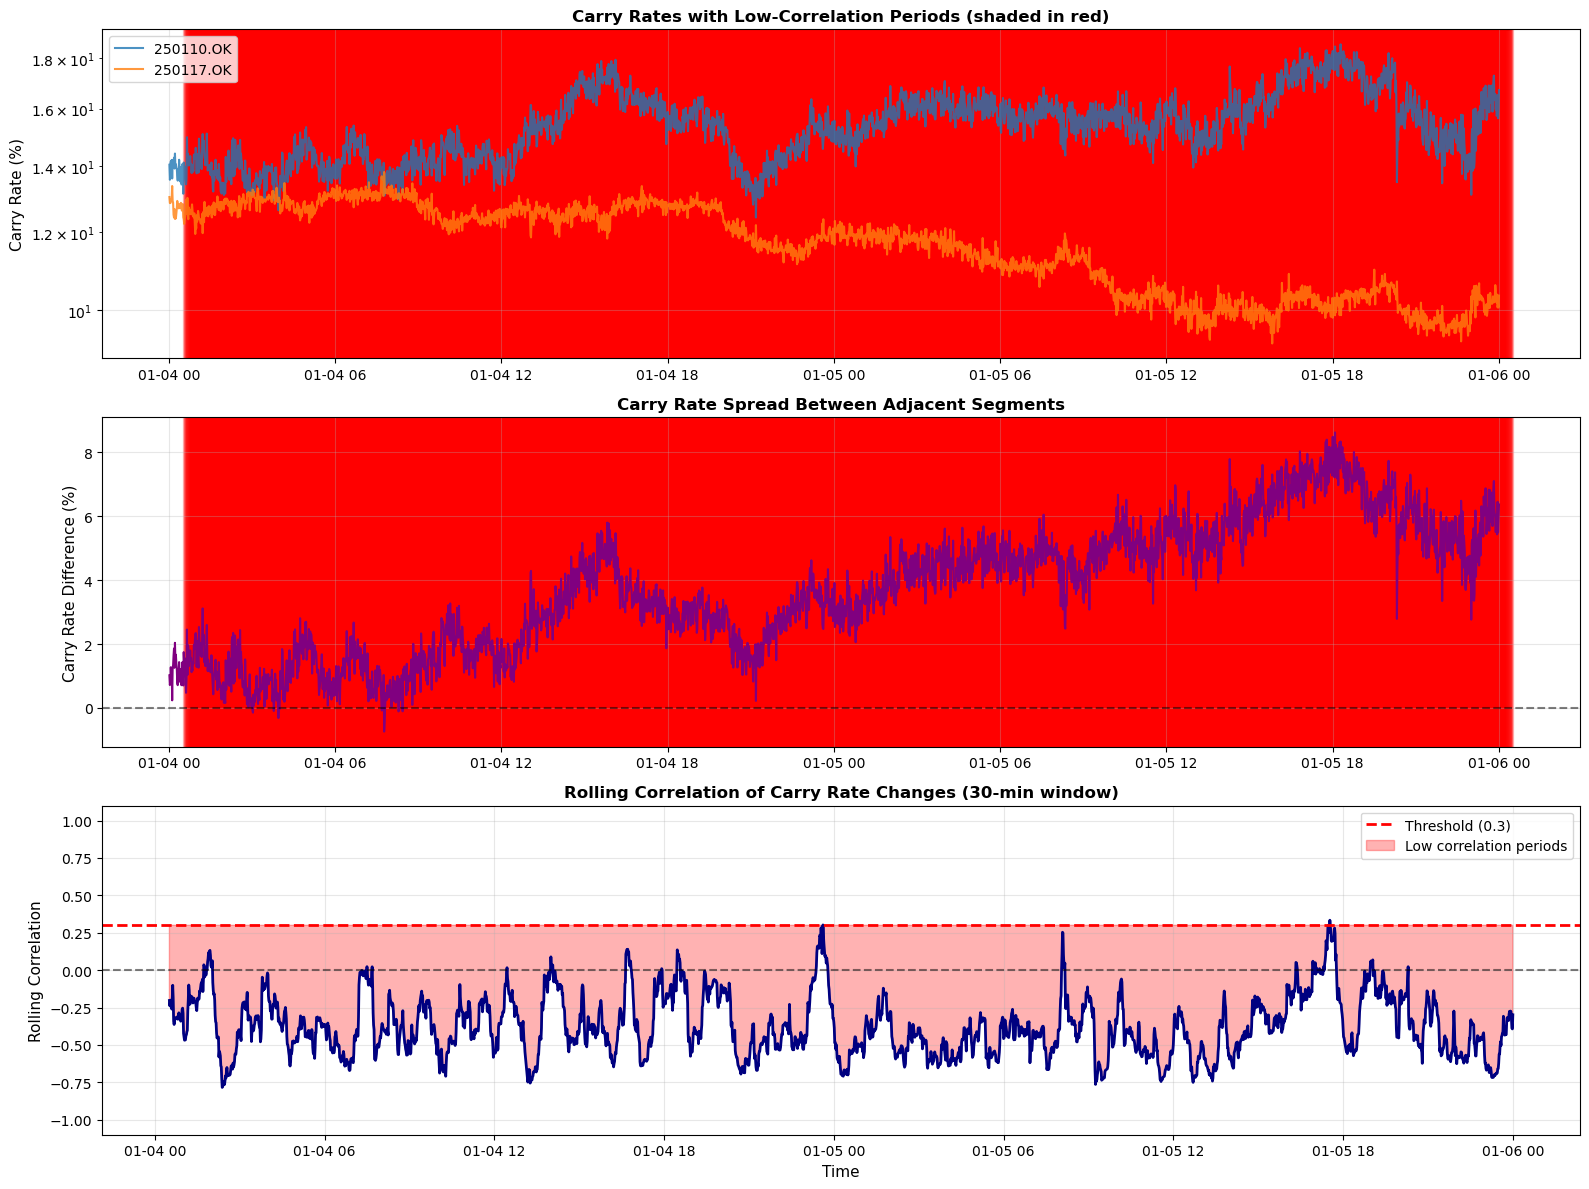


CHARACTERISTICS OF LOW CORRELATION PERIODS


ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [60]:
# ============================================================================
# IDENTIFY PERIODS OF CORRELATION BREAKDOWN
# ============================================================================

print("\n" + "="*80)
print("CORRELATION BREAKDOWN ANALYSIS")
print("="*80)

# Compute instantaneous correlation by looking at changes
# We'll use a short window to detect periods where segments move differently
short_window = 30  # 30 minutes

# Get the first two adjacent segments for detailed analysis
segment_cols = list(carry_pivot.columns)
if len(segment_cols) >= 2:
    seg1 = segment_cols[0]
    seg2 = segment_cols[1]
    
    # Compute returns (changes in carry rates)
    carry_returns = carry_pivot.diff()
    
    # Compute rolling correlation on returns
    rolling_corr_returns = carry_returns[seg1].rolling(window=short_window).corr(carry_returns[seg2])
    
    # Find periods where correlation is low or negative
    low_corr_threshold = 0.3
    low_corr_periods = rolling_corr_returns[rolling_corr_returns < low_corr_threshold].dropna()
    
    print(f"\nAnalyzing correlation between:")
    print(f"  Segment 1: {seg1}")
    print(f"  Segment 2: {seg2}")
    print(f"\nPeriods with correlation < {low_corr_threshold} (using {short_window}-min window):")
    print(f"  Total time periods: {len(low_corr_periods)}")
    print(f"  Percentage of time: {len(low_corr_periods) / len(rolling_corr_returns.dropna()) * 100:.2f}%")
    
    if len(low_corr_periods) > 0:
        print(f"\n  Examples of low correlation periods:")
        for i, (time, corr) in enumerate(low_corr_periods.head(5).items()):
            print(f"    {time}: correlation = {corr:.3f}")
    
    # Visualize the time series with correlation breakdown periods
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # Plot 1: Carry rates for both segments
    ax = axes[0]
    ax.plot(carry_pivot.index, carry_pivot[seg1], label=seg1.split('→')[-1].split('-')[-1], 
            linewidth=1.5, alpha=0.8)
    ax.plot(carry_pivot.index, carry_pivot[seg2], label=seg2.split('→')[-1].split('-')[-1], 
            linewidth=1.5, alpha=0.8)
    
    # Highlight low correlation periods
    if len(low_corr_periods) > 0:
        for time in low_corr_periods.index:
            ax.axvspan(time, time + timedelta(minutes=short_window), 
                      alpha=0.2, color='red', zorder=0)
    
    ax.set_ylabel('Carry Rate (%)', fontsize=11)
    ax.set_title('Carry Rates with Low-Correlation Periods (shaded in red)', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Plot 2: Difference between segments
    ax = axes[1]
    carry_diff = carry_pivot[seg1] - carry_pivot[seg2]
    ax.plot(carry_pivot.index, carry_diff, color='purple', linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Highlight low correlation periods
    if len(low_corr_periods) > 0:
        for time in low_corr_periods.index:
            ax.axvspan(time, time + timedelta(minutes=short_window), 
                      alpha=0.2, color='red', zorder=0)
    
    ax.set_ylabel('Carry Rate Difference (%)', fontsize=11)
    ax.set_title('Carry Rate Spread Between Adjacent Segments', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Rolling correlation
    ax = axes[2]
    ax.plot(rolling_corr_returns.index, rolling_corr_returns.values, 
            linewidth=2, color='navy')
    ax.axhline(y=low_corr_threshold, color='red', linestyle='--', 
              label=f'Threshold ({low_corr_threshold})', linewidth=2)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax.fill_between(rolling_corr_returns.index, rolling_corr_returns.values, 
                     low_corr_threshold, where=(rolling_corr_returns < low_corr_threshold),
                     alpha=0.3, color='red', label='Low correlation periods')
    
    ax.set_xlabel('Time', fontsize=11)
    ax.set_ylabel('Rolling Correlation', fontsize=11)
    ax.set_title(f'Rolling Correlation of Carry Rate Changes ({short_window}-min window)', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.1, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    # Analyze what happens during low correlation periods
    if len(low_corr_periods) > 0:
        print("\n" + "="*80)
        print("CHARACTERISTICS OF LOW CORRELATION PERIODS")
        print("="*80)
        
        # Get data for low vs high correlation periods
        low_corr_mask = rolling_corr_returns < low_corr_threshold
        high_corr_mask = rolling_corr_returns > 0.7
        
        # Compute volatility during these periods
        seg1_vol_low = carry_returns[seg1][low_corr_mask.shift(short_window)].std()
        seg1_vol_high = carry_returns[seg1][high_corr_mask.shift(short_window)].std()
        seg2_vol_low = carry_returns[seg2][low_corr_mask.shift(short_window)].std()
        seg2_vol_high = carry_returns[seg2][high_corr_mask.shift(short_window)].std()
        
        print(f"\nVolatility comparison (% per minute):")
        print(f"  {seg1.split('→')[-1].split('-')[-1]}:")
        print(f"    During low correlation: {seg1_vol_low:.6f}")
        print(f"    During high correlation: {seg1_vol_high:.6f}")
        print(f"    Ratio (low/high): {seg1_vol_low/seg1_vol_high:.2f}x")
        print(f"  {seg2.split('→')[-1].split('-')[-1]}:")
        print(f"    During low correlation: {seg2_vol_low:.6f}")
        print(f"    During high correlation: {seg2_vol_high:.6f}")
        print(f"    Ratio (low/high): {seg2_vol_low/seg2_vol_high:.2f}x")
        
        # Compute spread volatility
        spread_vol_low = carry_diff[low_corr_mask.shift(short_window)].diff().std()
        spread_vol_high = carry_diff[high_corr_mask.shift(short_window)].diff().std()
        
        print(f"\n  Spread volatility:")
        print(f"    During low correlation: {spread_vol_low:.6f}")
        print(f"    During high correlation: {spread_vol_high:.6f}")
        print(f"    Ratio (low/high): {spread_vol_low/spread_vol_high:.2f}x")

print("\n" + "="*80)
print("SUMMARY OF FINDINGS")
print("="*80)
print("""
This analysis reveals:

1. NOISE PATTERNS:
   - Shorter-dated forwards (near-term futures) exhibit higher absolute volatility
   - When normalized by √tenor, the noise is more comparable across tenors
   - This suggests that noise scales roughly with the square root of time to maturity

2. CORRELATION STRUCTURE:
   - Forward prices are highly correlated (typically > 0.99) - they track the underlying
   - Carry rates show more variation in correlation, especially between non-adjacent tenors
   - Adjacent segments tend to have higher correlation than distant ones

3. TIME-VARYING CORRELATIONS:
   - Correlations are not constant - they vary significantly over time
   - Low correlation periods exist, indicating the curve can twist/deform
   - During low correlation periods, the spread between segments becomes more volatile
   
4. IMPLICATIONS:
   - Different tenor segments can and do move independently at times
   - The forward curve is not always a parallel shift
   - Risk management should account for curve reshaping, not just level changes
""")
